#### [ CNN CUSTOM DATASET + MODEL ]

- 사용자 정의 이미지 데이터셋 생성 ==> ImageFolder 사용
- 사용자 정의 cnn기반 모델 설계
- 데이터 : 강아지, 고양이 사진



[1] 모듈 로딩 및 데이터 준비 <hr>

In [1]:
## 모듈 로딩
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.utils
import torch.utils.data

from torchvision.datasets import ImageFolder            ## 이미지용 데이터셋 생성 모듈
from torch.utils.data import DataLoader                 ## 데이터로더
from torchvision.transforms import transforms           ## 이미지 전처리 및 증강 모듈


import matplotlib.pyplot as plt


In [2]:
import pandas as pd

In [3]:
## 데이터 준비
# IMG_ROOT = '../_image/cat_dog/'
# IMG_TRAIN_ROOT = '../_image/cat_dog_train/'
IMG_ROOT = '../_image/test1/'
IMG_TRAIN_ROOT = '../_image/train1/'

[2] 데이터 로딩 및 데이터셋 준비 <hr>

In [4]:
# print(f"classes  => {imgDS.classes}")
# print(f"class_to_idx  => {imgDS.class_to_idx}")
# print(f"targets  => {imgDS.targets}")
# print(f"imgs  => {imgDS.imgs}")
# print(imgDS[0])

In [5]:
from PIL import Image

In [6]:
## 2-0 이미지 전처리 및 변형
## resize - > 이미지 크기 통일      ==> transforms.Resize((shape))
## tensor --> 텐서로 타입 변형.     ==> transforms.ToTensor() : 텐서화 + 정규화(0~1)
##                                  ==>                         채널(C, H, W)로 변경.
preprocessing = transforms.Compose(
    [
        transforms.Resize((50,50)),
        transforms.RandomHorizontalFlip(),   # 좌우 뒤집기
        transforms.RandomRotation(30),       # 랜덤 회전 (-30도 ~ 30도)
        transforms.ColorJitter(brightness=0.5, contrast=0.5),
        transforms.ToTensor()
    ]
    )

testDS = ImageFolder(IMG_ROOT, transform=preprocessing)
trainDS = ImageFolder(IMG_TRAIN_ROOT, transform=preprocessing)


In [7]:
data_list = []

# 데이터셋에서 이미지 경로와 라벨 정보 추출
for img_path, label in trainDS.imgs:
    filename = img_path.split("/")[-1]  # 파일명만 추출
    label_name = trainDS.classes[label]  # 라벨명 가져오기
    
    data_list.append({
        "filename": filename,
        "label": label_name,
        "transformations": "Grayscale, Resize(50,50), RandomHorizontalFlip, RandomRotation(30), ColorJitter(0.5), ToTensor"
    })

# CSV로 저장
df = pd.DataFrame(data_list)
df.to_csv("trainDS_data.csv", index=False)

In [8]:
testDS

Dataset ImageFolder
    Number of datapoints: 35
    Root location: ../_image/test1/
    StandardTransform
Transform: Compose(
               Resize(size=(50, 50), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=None, hue=None)
               ToTensor()
           )

In [9]:
trainDS

Dataset ImageFolder
    Number of datapoints: 103
    Root location: ../_image/train1/
    StandardTransform
Transform: Compose(
               Resize(size=(50, 50), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=None, hue=None)
               ToTensor()
           )

In [10]:
### CNN으로 캣/독 이진분류.

class CD_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        ## 특징맵 추출 부분
        self.con_layer1 = nn.Conv2d(3, 16, 3, padding=1)  # (1, 3, 50, 50) -> (1, 16, 50, 50)
        self.pool_layer1 = nn.MaxPool2d(2, 2)             # (1, 16, 50, 50) -> (1, 16, 50, 50)
        self.con_layer2 = nn.Conv2d(16, 32, 3, padding=1) # (1, 16, 50, 50) -> (1, 32, 50, 50)
        self.pool_layer2 = nn.MaxPool2d(2, 2)             # (1, 32, 50, 50) -> (1, 32, 25, 25)
        
        self.flat_layer = nn.Flatten()                    # (1, 32, 25, 25) -> (1, 32*25*25)
        
        ## 전결합 학습 부분
        self.fc_layer1 = nn.Linear(32*12*12, 512)
        self.h_layer1 = nn.Linear(512, 128)
        self.drop = nn.Dropout(0.25)  # Dropout2d 대신 Dropout 사용
        self.out_layer = nn.Linear(128, 1)  # 이진 분류 (출력 노드 1개)
        
    def forward(self, x):
        x = self.pool_layer1(nn.ReLU()(self.con_layer1(x)))
        x = self.pool_layer2(nn.ReLU()(self.con_layer2(x)))
        x = self.flat_layer(x)
        x = nn.ReLU()(self.fc_layer1(x))
        x = nn.ReLU()(self.h_layer1(x))
        x = self.drop(x)
        x = self.out_layer(x)  
        return x
        



In [11]:
test = CD_CNN()

In [12]:
import sys

sys.path.append('../_utils/')
from DL_Module import TT_classifier

In [13]:
testCF = TT_classifier(test, trainDS, testDS, LOSS_FN=nn.BCEWithLogitsLoss())

EPOCHS : 100
ITERATION : 1
LOSS_FN : BCEWithLogitsLoss()


In [14]:
len(testDS)
for a, b in testDS:
    print( a.shape, b)
    break

torch.Size([3, 50, 50]) 0


In [15]:
# HIST = testCF.cycling()

In [16]:
# testCF.draw_graph()

In [17]:
HIST['Train']
HIST['Valid']

NameError: name 'HIST' is not defined

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
irisDS = load_iris()
# data, target


NameError: name 'load_iris' is not defined

In [ ]:
print(irisDS['data'].shape, irisDS['target'].shape)

(150, 4) (150,)


In [ ]:
featureDS = irisDS['data']
targetDS = irisDS['target']

In [ ]:
import tools as ts
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(irisDS['data'], irisDS['target'], stratify=irisDS['target'], random_state=42)

NameError: name 'irisDS' is not defined

In [18]:
testDF = pd.read_csv('../_data/fashion/fashion-mnist_test.csv')
trainDF = pd.read_csv('../_data/fashion/fashion-mnist_train.csv')

In [19]:
from DL_Module import Common_Dataset

In [20]:
trainDF.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
fas_trainDS = Common_Dataset(trainDF.iloc[:,1:], trainDF['label'])
fas_testDS = Common_Dataset(testDF.iloc[:,1:], testDF['label'])

In [22]:
28*28

784

In [23]:
class CD_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 입력 채널=1 (흑백), 출력 채널=32
        self.pool = nn.MaxPool2d(2, 2)  # 풀링 레이어 (2x2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # Conv 레이어 추가
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Fully Connected Layer
        self.fc2 = nn.Linear(128, 10)  # 출력층 (이진 분류)
        
    def forward(self, x):
        x = x.view(-1, 1, 28, 28)  # ✅ 784 → (1, 28, 28)로 변환
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = torch.flatten(x, 1)  # Feature 맵을 1차원으로 변환
        x = nn.ReLU()(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))  # 이진 분류 (0~1)
        return x


In [24]:
fasModel = CD_CNN()

In [25]:

from DL_Module import *

In [26]:
faslearn = TT_classifier(fasModel,fas_trainDS, fas_testDS, LOSS_FN=nn.CrossEntropyLoss())

EPOCHS : 100
ITERATION : 600
LOSS_FN : CrossEntropyLoss()


In [27]:
HIST = faslearn.cycling()

torch.Size([10000, 784])
torch.Size([10000, 1])

EPOCH[0/100]----------------
- TRAIN_LOSS 1.96604  ACC 0.43230
- VALID_LOSS 1.85796  ACC 0.57590
27.793142318725586
[0] - num_bad_epochs : 0 
torch.Size([10000, 784])
torch.Size([10000, 1])

EPOCH[1/100]----------------
- TRAIN_LOSS 1.85032  ACC 0.61173
- VALID_LOSS 1.85038  ACC 0.57810
27.45826816558838
[1] - num_bad_epochs : 0 
torch.Size([10000, 784])
torch.Size([10000, 1])

EPOCH[2/100]----------------
- TRAIN_LOSS 1.84564  ACC 0.63413
- VALID_LOSS 1.84151  ACC 0.63380
27.25464153289795
[2] - num_bad_epochs : 0 
torch.Size([10000, 784])
torch.Size([10000, 1])

EPOCH[3/100]----------------
- TRAIN_LOSS 1.83988  ACC 0.63284
- VALID_LOSS 1.83773  ACC 0.60190
27.896986961364746
[3] - num_bad_epochs : 0 
torch.Size([10000, 784])
torch.Size([10000, 1])

EPOCH[4/100]----------------
- TRAIN_LOSS 1.83883  ACC 0.61525
- VALID_LOSS 1.84169  ACC 0.60570
27.71718430519104
[4] - num_bad_epochs : 1 
torch.Size([10000, 784])
torch.Size([10000, 1])


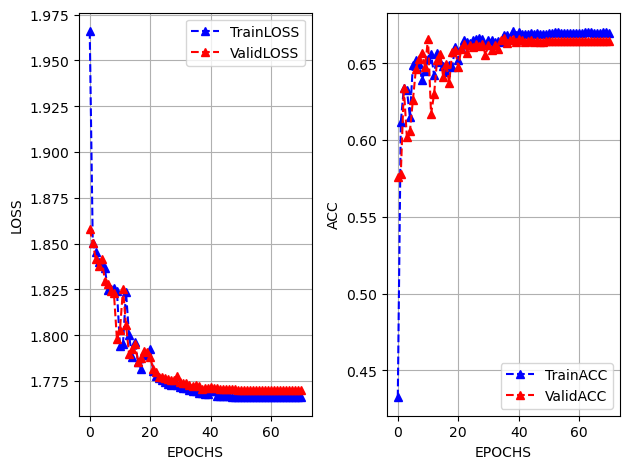

In [28]:
faslearn.draw_graph()